In [11]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf
import seaborn as sns
from arch import arch_model
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [12]:
# df_raw = pd.read_csv("data/nse_data.csv")
df_raw = pd.read_parquet("data/processed/crypto_daily_log_returns.parquet")
df_raw.head()

asset,BTC,ETH,SOL,XRP
close_time,,,,
2017-08-18 23:59:59.999000+00:00,-0.042113,-0.026983,NaN,NaN
2017-08-19 23:59:59.999000+00:00,0.007665,-0.010430,NaN,NaN
2017-08-20 23:59:59.999000+00:00,-0.013053,0.027764,NaN,NaN
2017-08-21 23:59:59.999000+00:00,-0.017351,0.077772,NaN,NaN
2017-08-22 23:59:59.999000+00:00,0.005958,-0.042623,NaN,NaN


In [13]:
df = df_raw.copy()

if "date" in df.columns:
    df["date"] = pd.to_datetime(df["date"], utc=True)
    df = df.set_index("date")
elif not isinstance(df.index, pd.DatetimeIndex):
    df.index = pd.to_datetime(df.index, utc=True)

df = df.sort_index()

if df.index.tz is not None:
    split_date = pd.Timestamp("2025-07-01", tz=df.index.tz)
else:
    split_date = pd.Timestamp("2025-07-01")

train = df.loc[df.index < split_date]
test = df.loc[df.index >= split_date]

train_returns = train.dropna(how="all")
test_returns = test.dropna(how="all")

print(f"Train rows: {len(train_returns)}")
print(f"Test rows: {len(test_returns)}")

print(train_returns.tail())
print(test_returns.head())

Train rows: 2874
Test rows: 366
asset                                  BTC       ETH       SOL       XRP
close_time                                                              
2025-06-26 23:59:59.999000+00:00 -0.003673 -0.001047 -0.031917 -0.037522
2025-06-27 23:59:59.999000+00:00  0.000940  0.002980  0.021555  0.017188
2025-06-28 23:59:59.999000+00:00  0.002325  0.005125  0.058963  0.020106
2025-06-29 23:59:59.999000+00:00  0.009832  0.026125  0.017103  0.009427
2025-06-30 23:59:59.999000+00:00 -0.011234 -0.005865  0.009671  0.013552
asset                                  BTC       ETH       SOL       XRP
close_time                                                              
2025-07-01 23:59:59.999000+00:00 -0.013771 -0.032908 -0.052583 -0.029130
2025-07-02 23:59:59.999000+00:00  0.029541  0.066511  0.036039  0.027966
2025-07-03 23:59:59.999000+00:00  0.006731  0.008075  0.000591  0.010378
2025-07-04 23:59:59.999000+00:00 -0.014713 -0.032639 -0.031063 -0.016260
2025-07-05 23:59:59

In [14]:
train_returns.to_parquet("data/processed/train_returns.parquet")
test_returns.to_parquet("data/processed/test_returns.parquet")
print("Train and test returns saved to parquet files.")

Train and test returns saved to parquet files.


In [15]:
train_returns.to_excel("data/processed/train_returns.xlsx", index=False)

In [16]:
# GARCH(1,1)
garch = arch_model(train_returns["BTC"].dropna(), vol="Garch", p=1, q=1, dist="t").fit(disp="off")
print("=== GARCH(1,1) ===")
print(garch.summary())
print("\n")

# pred = garch.forecast(horizon=30, reindex=False)
# print("=== GARCH(1,1) Forecast ===")
# print(pred.variance)
# pred.to_excel("data/processed/garch_forecast.xlsx", index=True)

=== GARCH(1,1) ===
                        Constant Mean - GARCH Model Results                         
Dep. Variable:                          BTC   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:                5916.75
Distribution:      Standardized Student's t   AIC:                          -11823.5
Method:                  Maximum Likelihood   BIC:                          -11793.7
                                              No. Observations:                 2873
Date:                      Tue, Jul 28 2026   Df Residuals:                     2872
Time:                              11:35:57   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
--------------------------------------------------------------

d:\Quant Research\.venv\Lib\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.001365. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


In [17]:
# param_name, value = garch.params.items()
# param_name = list(param_name)
# print(param_name)

rows = []

row = {}
for param_name, value in garch.params.items():
    row[f"param_{param_name}"] = value

rows.append(row)
rows

[{'param_mu': 0.0010823687498493543,
  'param_omega': 2.7307241724291328e-05,
  'param_alpha[1]': 0.04999976026177657,
  'param_beta[1]': 0.9299955408690441,
  'param_nu': 4.337636987223969}]

In [18]:
# Use the train set created earlier
train_df = train_returns.copy() if "train_returns" in globals() else train.copy()

# Select numeric asset columns
asset_cols = [
    c for c in train_df.columns
    if pd.api.types.is_numeric_dtype(train_df[c]) and c not in {"date"}
]

if len(asset_cols) == 0:
    raise ValueError("No numeric asset columns found.")

def make_excel_safe(df):
    df = df.copy()

    if isinstance(df.index, pd.DatetimeIndex) and df.index.tz is not None:
        df.index = df.index.tz_convert(None)

    for col in df.columns:
        if pd.api.types.is_datetime64tz_dtype(df[col]):
            df[col] = df[col].dt.tz_convert(None)

    return df

model_specs = [
    ("GARCH(1,1)", {"vol": "Garch", "p": 1, "o": 0, "q": 1}),
    ("GJR-GARCH(1,1)", {"vol": "Garch", "p": 1, "o": 1, "q": 1}),
    ("EGARCH(1,1)", {"vol": "EGARCH", "p": 1, "o": 1, "q": 1}),
]

model_summaries = []
model_var_dfs = []

for model_name, spec in model_specs:
    rows = []
    var_frames = []

    for asset in asset_cols:
        s = train_df[asset].dropna()*100

        if len(s) < 50:
            continue

        model = arch_model(
            s,
            vol=spec["vol"],
            p=spec["p"],
            o=spec["o"],
            q=spec["q"],
            dist="t"
        ).fit(disp="off", show_warning=False)

        cond_var = pd.Series(model.conditional_volatility**2/10000, index=s.index, name=asset)
        var_frames.append(cond_var.to_frame())

        row = {
            "asset": asset,
            "model": model_name,
            "aic": model.aic,
            "bic": model.bic,
            "n_obs": len(s),
        }

        for param_name, value in model.params.items():
            row[f"param_{param_name}"] = value

        rows.append(row)

    if len(rows) > 0:
        model_df = pd.DataFrame(rows)
        var_df = pd.concat(var_frames, axis=1)

        model_df = make_excel_safe(model_df)
        var_df = make_excel_safe(var_df)

        model_summaries.append(model_df)
        model_var_dfs.append((model_name, var_df))

summary_df = pd.concat(model_summaries, ignore_index=True) if model_summaries else pd.DataFrame()
combined_var_df = pd.concat(
    [var_df.add_prefix(f"{model_name}::") for model_name, var_df in model_var_dfs],
    axis=1
) if model_var_dfs else pd.DataFrame()

summary_df = make_excel_safe(summary_df)
combined_var_df = make_excel_safe(combined_var_df)

os.makedirs("data/models", exist_ok=True)
out_file = "data/models/daily_data_arch_models_all.xlsx"

with pd.ExcelWriter(out_file, engine="openpyxl") as writer:
    summary_df.to_excel(writer, sheet_name="model_summary", index=False)
    combined_var_df.to_excel(writer, sheet_name="all_model_variances")

print(f"Saved all model results to: {out_file}")
print("\nModel summary dataframe:")
print(summary_df.head())

print("\nCombined variance dataframe:")
print(combined_var_df.head())

C:\Users\Shivam\AppData\Local\Temp\ipykernel_51956\118465274.py:71: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  var_df = pd.concat(var_frames, axis=1)
C:\Users\Shivam\AppData\Local\Temp\ipykernel_51956\118465274.py:20: Pandas4Warning: is_datetime64tz_dtype is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.DatetimeTZDtype)` instead.
  if pd.api.types.is_datetime64tz_dtype(df[col]):
C:\Users\Shivam\AppData\Local\Temp\ipykernel_51956\118465274.py:20: Pandas4Warning: is_datetime64tz_dtype is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.DatetimeTZDtype)` instead.
  if pd.api.types.is_datetime64tz_dtype(df[col]):
C:\Users\Shivam\AppData\Local\Temp\ipykernel_51956\118465274.py

Saved all model results to: data/models/daily_data_arch_models_all.xlsx

Model summary dataframe:
  asset           model           aic           bic  n_obs  param_mu  \
0   BTC      GARCH(1,1)  14571.847713  14601.663273   2873  0.091987   
1   ETH      GARCH(1,1)  16169.470561  16199.286121   2873  0.085615   
2   SOL      GARCH(1,1)  11160.843743  11188.276810   1784  0.023981   
3   XRP      GARCH(1,1)  14586.499077  14615.842261   2614 -0.072513   
4   BTC  GJR-GARCH(1,1)  14573.689857  14609.468529   2873  0.093115   

   param_omega  param_alpha[1]  param_beta[1]  param_nu  param_gamma[1]  
0     0.138166        0.070549       0.929451  3.164156             NaN  
1     0.532200        0.109178       0.890822  3.253821             NaN  
2     1.745421        0.118464       0.841379  4.794794             NaN  
3     2.172246        0.263241       0.736759  2.873182             NaN  
4     0.131152        0.072043       0.931044  3.169625       -0.006173  

Combined variance datafr

In [19]:
def make_excel_safe(df):
    df = df.copy()

    if isinstance(df.index, pd.DatetimeIndex) and df.index.tz is not None:
        df.index = df.index.tz_convert(None)

    for col in df.columns:
        if pd.api.types.is_datetime64tz_dtype(df[col]):
            df[col] = df[col].dt.tz_convert(None)

    return df

df_squared_returns = (train_returns**2).copy()
df_squared_returns = make_excel_safe(df_squared_returns)
df_squared_returns.to_excel("data/processed/daily_squared_returns.xlsx", index=True)
df_squared_returns.head()

# metrics_df = make_excel_safe(metrics_df)
# metrics_df.to_excel("data/processed/variance_metrics_all_assets.xlsx", index=False) 

C:\Users\Shivam\AppData\Local\Temp\ipykernel_51956\2003823832.py:8: Pandas4Warning: is_datetime64tz_dtype is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.DatetimeTZDtype)` instead.
  if pd.api.types.is_datetime64tz_dtype(df[col]):


asset,BTC,ETH,SOL,XRP
close_time,,,,
2017-08-18 23:59:59.999,0.001773,0.000728,NaN,NaN
2017-08-19 23:59:59.999,0.000059,0.000109,NaN,NaN
2017-08-20 23:59:59.999,0.000170,0.000771,NaN,NaN
2017-08-21 23:59:59.999,0.000301,0.006048,NaN,NaN
2017-08-22 23:59:59.999,0.000036,0.001817,NaN,NaN


In [20]:
returns_file = "data/processed/daily_squared_returns.xlsx"
variance_file = "data/models/daily_data_arch_models_all.xlsx"

returns_df = pd.read_excel(
    returns_file,
    sheet_name="Sheet1"
)

variance_df = pd.read_excel(
    variance_file,
    sheet_name="all_model_variances"
)

# Convert timestamps to datetime
returns_df["close_time"] = pd.to_datetime(
    returns_df["close_time"],
    errors="coerce"
)

variance_df["close_time"] = pd.to_datetime(
    variance_df["close_time"],
    errors="coerce"
)

combined_df = returns_df.merge(
    variance_df,
    on="close_time",
    how="inner"
)

assets = ["BTC", "ETH", "SOL", "XRP"]

models = [
    "GARCH(1,1)",
    "GJR-GARCH(1,1)",
    "EGARCH(1,1)"
]

results = []

for asset in assets:

    squared_return = combined_df[asset] ** 2

    for model in models:

        variance_column = f"{model}::{asset}"

        # Keep only observations where both values are available
        evaluation_df = pd.DataFrame({
            "squared_return": squared_return,
            "conditional_variance": combined_df[variance_column]
        }).replace([np.inf, -np.inf], np.nan).dropna()

        if evaluation_df.empty:
            print(
                f"No valid observations available for "
                f"{asset} using {model}"
            )
            continue

        actual = evaluation_df["squared_return"]
        predicted = evaluation_df["conditional_variance"]

        mae = mean_absolute_error(actual, predicted)

        rmse = np.sqrt(
            mean_squared_error(actual, predicted)
        )

        results.append({
            "Asset": asset,
            "Model": model,
            "Observations": len(evaluation_df),
            "MAE": mae,
            "RMSE": rmse
        })

# Convert results into a DataFrame
error_metrics_df = pd.DataFrame(results)

print(error_metrics_df)

# Display results sorted by asset and RMSE
# ranked_results_df = error_metrics_df.sort_values(
#     by=["Asset", "RMSE"],
#     ascending=[True, True]
# ).reset_index(drop=True)

# print("\nModels ranked by RMSE:")
# print(ranked_results_df)

   Asset           Model  Observations       MAE      RMSE
0    BTC      GARCH(1,1)          2873  0.001580  0.002448
1    BTC  GJR-GARCH(1,1)          2873  0.001570  0.002419
2    BTC     EGARCH(1,1)          2873  0.001932  0.002756
3    ETH      GARCH(1,1)          2873  0.002746  0.004362
4    ETH  GJR-GARCH(1,1)          2873  0.002766  0.004418
5    ETH     EGARCH(1,1)          2873  0.002673  0.003925
6    SOL      GARCH(1,1)          1784  0.004179  0.006100
7    SOL  GJR-GARCH(1,1)          1784  0.004184  0.006132
8    SOL     EGARCH(1,1)          1784  0.004055  0.005488
9    XRP      GARCH(1,1)          2614  0.003731  0.007428
10   XRP  GJR-GARCH(1,1)          2614  0.003740  0.007456
11   XRP     EGARCH(1,1)          2614  0.003825  0.015665


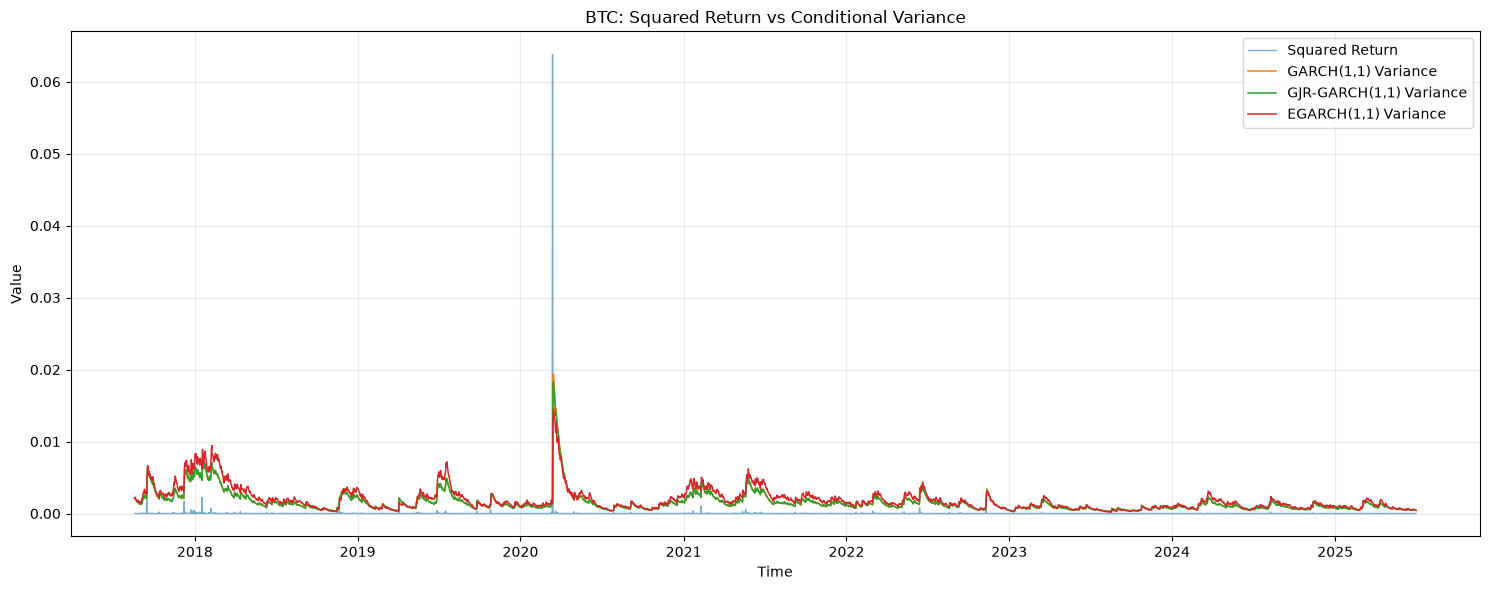

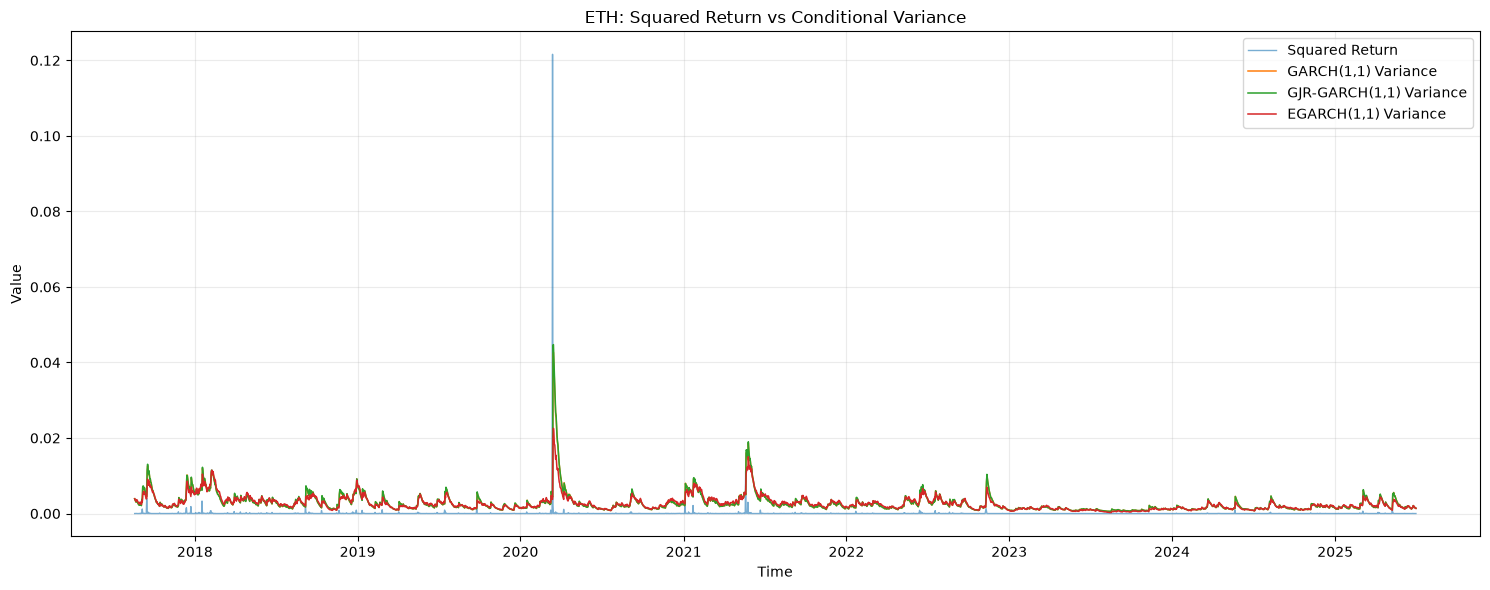

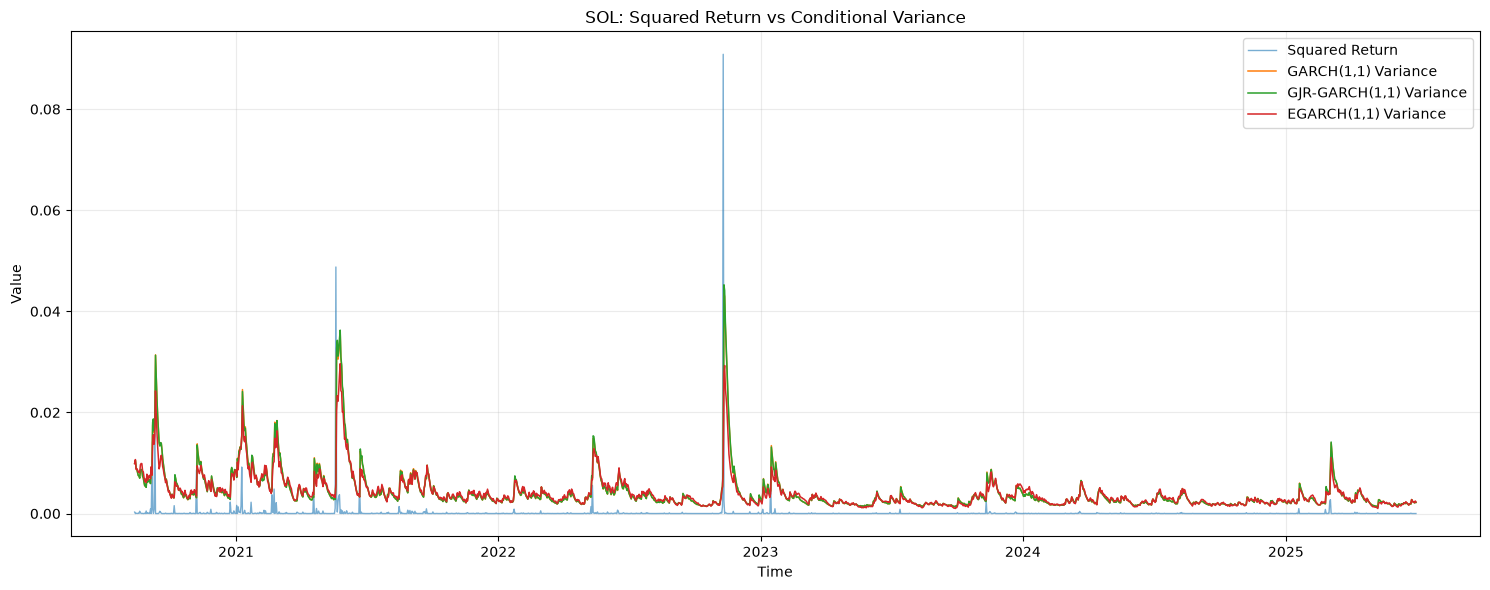

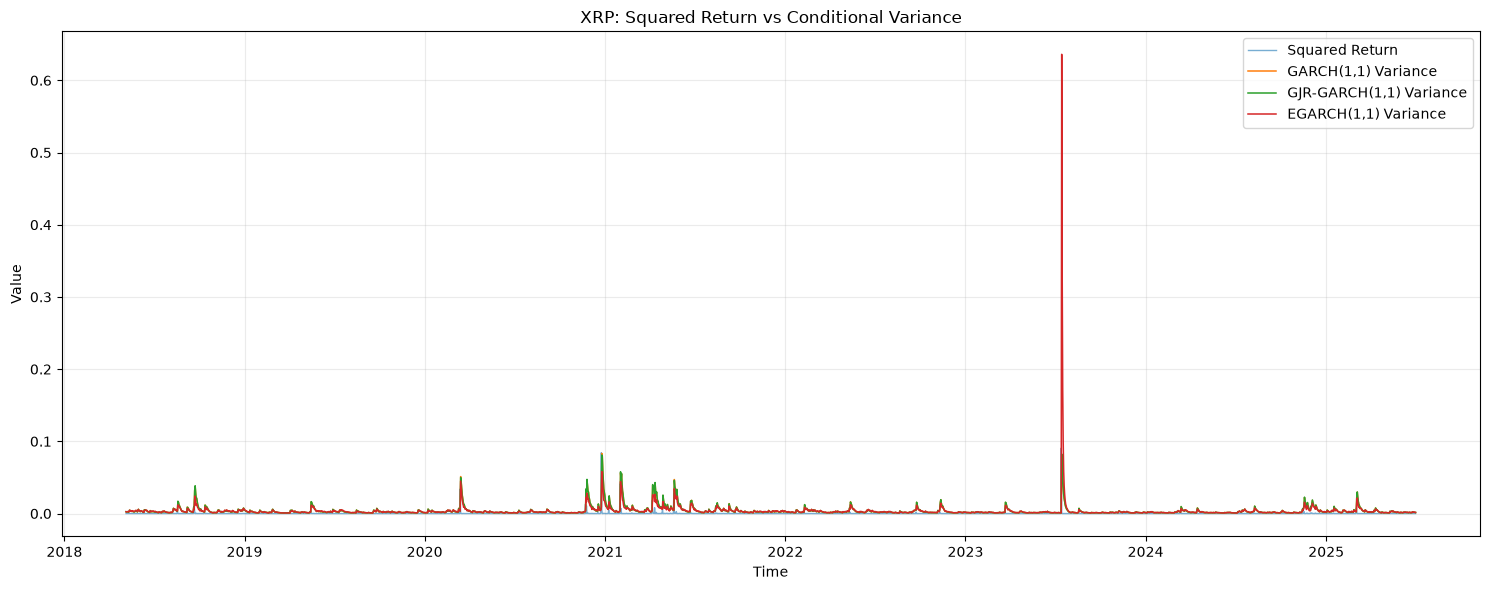

In [21]:
returns_file = "data/processed/daily_squared_returns.xlsx"
variance_file = "data/models/daily_data_arch_models_all.xlsx"

def read_time_index_excel(path, sheet_name):
    df = pd.read_excel(path, sheet_name=sheet_name, index_col=0)
    df.index = pd.to_datetime(df.index, errors="coerce")
    df.index.name = "close_time"
    return df.reset_index()

returns_df = read_time_index_excel(returns_file, sheet_name="Sheet1")
variance_df = read_time_index_excel(variance_file, sheet_name="all_model_variances")

plot_df = returns_df.merge(variance_df, on="close_time", how="inner").sort_values("close_time")

assets = ["BTC", "ETH", "SOL", "XRP"]
models = ["GARCH(1,1)", "GJR-GARCH(1,1)", "EGARCH(1,1)"]
# models = ["GARCH(1,1)"]

for asset in assets:
    variance_columns = [f"{model}::{asset}" for model in models]
    required_columns = ["close_time", asset] + variance_columns
    asset_df = plot_df[required_columns].dropna(subset=[asset] + variance_columns, how="all").copy()

    if asset_df.empty:
        continue

    asset_df["Squared Return"] = asset_df[asset].pow(2)

    plt.figure(figsize=(15, 6))
    plt.plot(asset_df["close_time"], asset_df["Squared Return"], label="Squared Return", linewidth=1.0, alpha=0.6)

    for model, variance_column in zip(models, variance_columns):
        if variance_column in asset_df.columns:
            plt.plot(asset_df["close_time"], asset_df[variance_column], label=f"{model} Variance", linewidth=1.1)

    plt.title(f"{asset}: Squared Return vs Conditional Variance")
    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()